# Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# I.Read data

In [2]:
columns = ["Invoice ID","Branch","City","Customer type","Gender","Product line","Unit price","Quantity","Tax 5%","Sales","Date","Time","Payment","Cogs","Gross margin percentage","Gross income","Rating"]

In [3]:
supermarket = pd.read_csv("SuperMarket Analysis.csv", names=columns, sep=",", skiprows=1, skipinitialspace=True)

In [4]:
supermarket

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,Cogs,Gross margin percentage,Gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [5]:
supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  Cogs                     1000 non-null   float64
 14  Gross margin percentage  

In [6]:
numerical_cols= ["Unit price","Quantity","Tax 5%","Sales","Cogs","Gross income","Rating"]

In [7]:
supermarket[numerical_cols].describe()

,Unit price,Quantity,Tax 5%,Sales,Cogs,Gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,49.650000,10.00000


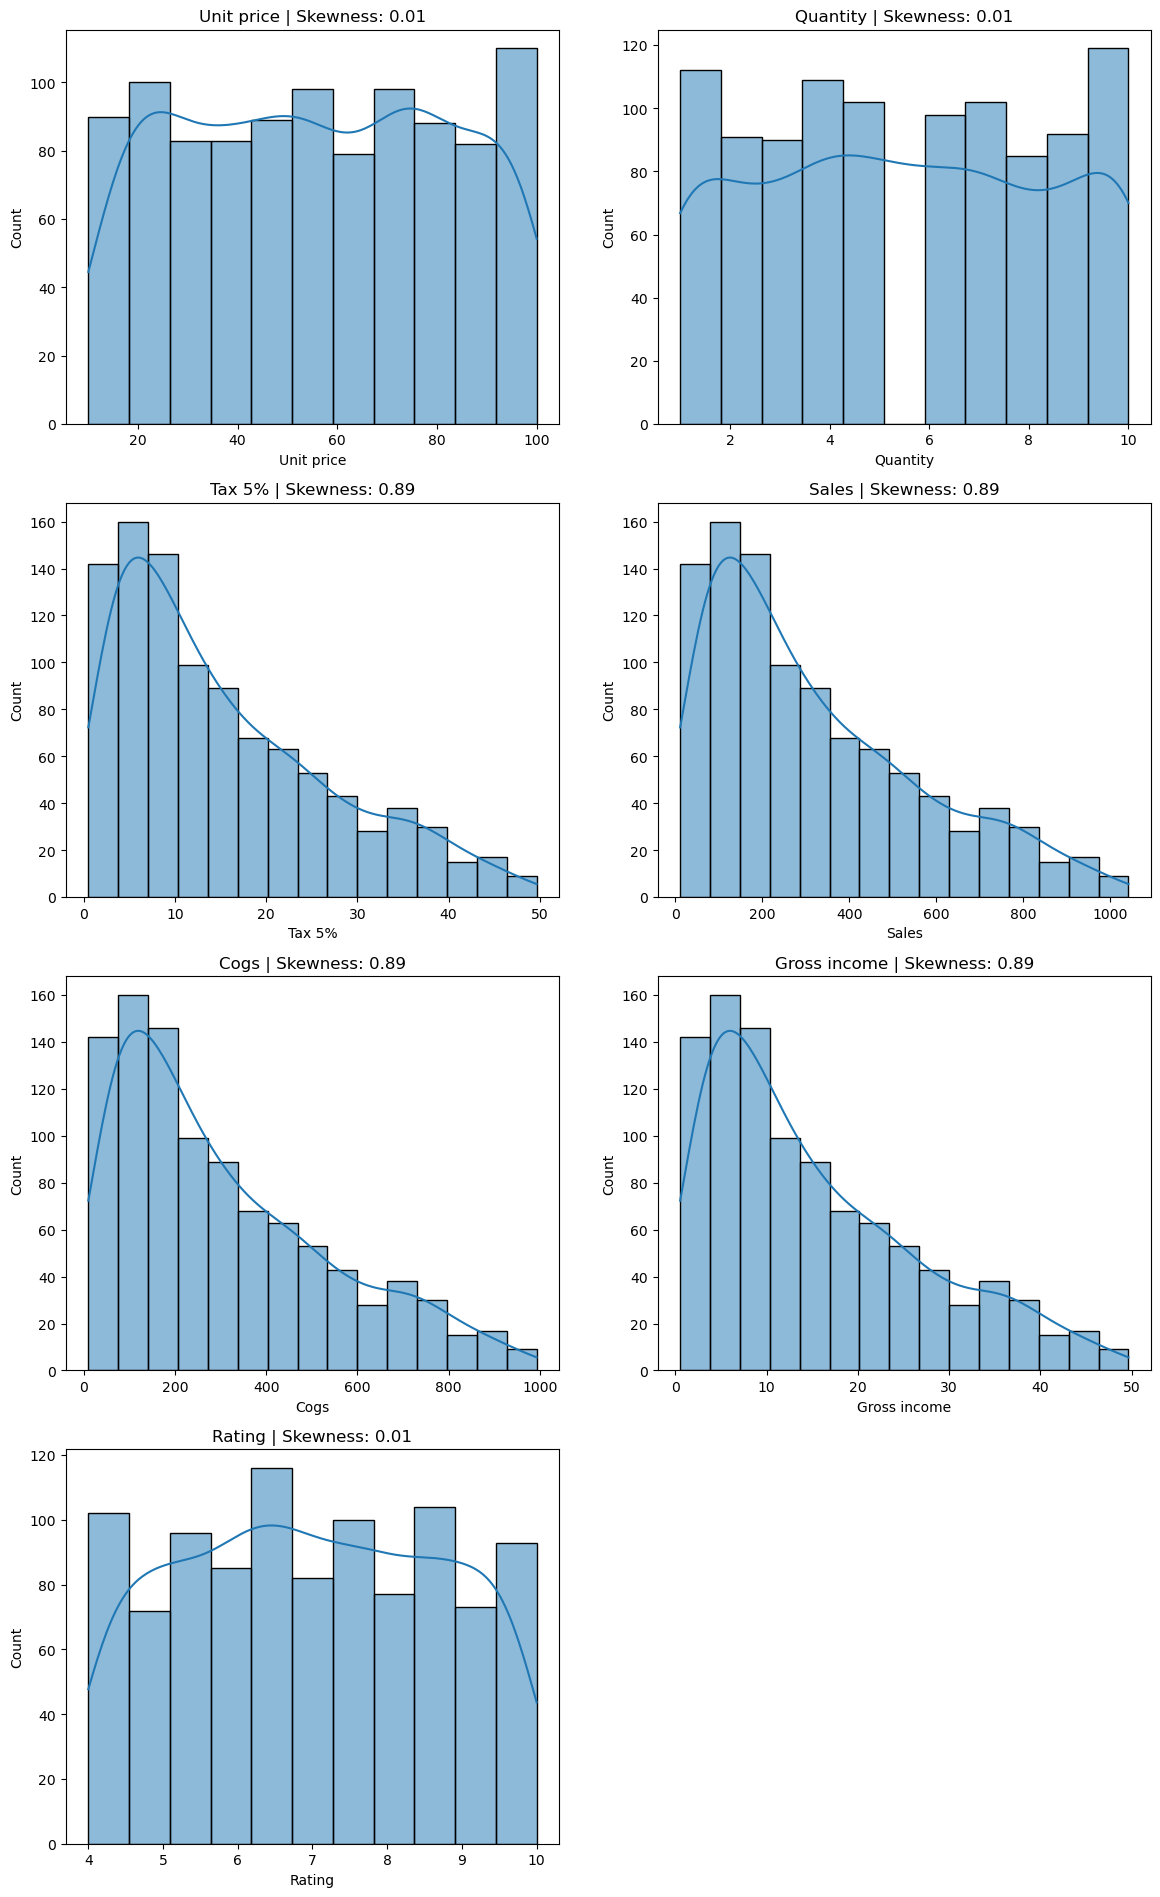

In [8]:
plt.figure(figsize=(14, len(numerical_cols) * 6)) 
for idx, feature in enumerate(numerical_cols, 1): 
    plt.subplot(len(numerical_cols), 2, idx) 
    sns.histplot(supermarket[feature], kde=True) 
    plt.title(f"{feature} | Skewness: {round(supermarket[feature].skew(), 2)}")


# II.Clean data

## 2.1 Missing data

In [9]:
null_count = supermarket.isnull().sum()
print("Null value: ")
print(null_count)

Null value: 
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
Cogs                       0
Gross margin percentage    0
Gross income               0
Rating                     0
dtype: int64


In [10]:
empty_data = ((supermarket == '?') | (supermarket == '')).sum()
print('Empty data: ')
print(empty_data)

Empty data: 
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
Cogs                       0
Gross margin percentage    0
Gross income               0
Rating                     0
dtype: int64


## 2.2 Duplicate data

In [11]:
duplicate_count = supermarket.duplicated().sum()
print('Duplicate rows: ', duplicate_count)

Duplicate rows:  0


# III. Analysis Questions

Here are some analysis questions, and I will answer them based on the graphs I created in Power BI.

### 1. How are sales distributed across different product lines?

Based on the Overall page in Power BI, all product lines show relatively similar sales, with Food and Beverages having the highest sales at over 56K, while Health and Beauty records the lowest at 49K.

### 2. Which city shows the highest sales performance, and how do sales compare across cities?

According to the pie chart in the 1st page, all three cities contribute around 30% of the total sales, with Naypyitaw holding the highest share at 34.24%.

### 3. Which payment method is used the most in Naypyitaw, and which product line uses this payment method the most in Naypyitaw?

The Payment and Consumer Purchasing Trend slide shows that customers use cash the most, spending primarily on Food and Beverages (11K), followed by Electronic Accessories (10K) in Naypyitaw.

### 4. How is the distribution of product lines across cities?

In the 2nd slide, Naypyitaw records the highest sales in Health and Beauty (24K) and Fashion Accessories (22K), while Yangon leads in Sports and Travel (22K) and Home and Lifestyle (19K). Mandalay shows more balanced sales, with Home and Lifestyle (20K) and Sports and Travel (20K) performing strongly. Overall, each city has distinct top-selling product lines, reflecting different consumer preferences.

### 5. What can you say about customer buying habits for different product lines based on gender in each city?

We can answer this question based on the graph in the ‘Sales by Gender’ slide.

In Mandalay, females purchase more in categories like Sports and Travel (12.1K) and Food and Beverages (10.5K), while males slightly lead in Health and Beauty (10.7K). In Naypyitaw, females dominate Food and Beverages (17.4K) and Fashion Accessories (14.3K), but males purchase more in Health and Beauty (10K). In Yangon, females lead strongly in Home and Lifestyle (14.3K) and Sports and Travel (11.9K), whereas male spending is more balanced, with relatively higher shares in Food and Beverages (8.6K).

Overall, female customers tend to spend more across most product lines, especially in lifestyle and travel-related categories, while male customers show stronger preferences in Health and Beauty and certain food categories, depending on the city.